In [ ]:
!pip show kaggle


In [ ]:
import os
import shutil

os.makedirs('/Users/sunnybhupati/.kaggle', exist_ok=True)

shutil.copy(
    '/Users/sunnybhupati/kagggle/kaggle.json',
    '/Users/sunnybhupati/.kaggle/kaggle.json'
)
print("Copied! ✅")

In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/Users/sunnybhupati/kagggle'

In [ ]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/Users/sunnybhupati/kagggle/kaggle.json'

import kaggle
kaggle.api.authenticate()
print("Authenticated Successfully! ✅")

In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = '/Users/sunnybhupati/kagggle/kaggle.json'


In [ ]:
!pip uninstall -y kaggle kagglesdk
!pip install --no-cache-dir kagglesdk kaggle

In [ ]:
import os

os.environ["KAGGLE_CONFIG_DIR"] = "/Users/sunnybhupati/kagggle"

import kaggle
kaggle.api.authenticate()

print("Authenticated Successfully! ✅")

In [ ]:
import sys
print(sys.executable)

In [ ]:
import sys

!{sys.executable} -m pip uninstall -y kaggle kagglesdk
!{sys.executable} -m pip install --no-cache-dir --force-reinstall kagglesdk kaggle

In [ ]:
import os

os.environ["KAGGLE_CONFIG_DIR"] = "/Users/sunnybhupati/kagggle"

import kaggle
kaggle.api.authenticate()

print("Authenticated Successfully! ✅")

In [ ]:
import sys
print(sys.executable)

In [ ]:
import sys

!{sys.executable} -m pip uninstall -y kaggle kagglesdk
!{sys.executable} -m pip install --no-cache-dir --force-reinstall kaggle kagglesdk

In [ ]:
import os

os.environ["KAGGLE_CONFIG_DIR"] = "/Users/sunnybhupati/kagggle"

import kaggle
kaggle.api.authenticate()

print("Authenticated Successfully! ✅")

In [ ]:
import sys

!{sys.executable} -m pip uninstall -y kaggle kagglesdk
!{sys.executable} -m pip cache purge

In [ ]:
import sys

!{sys.executable} -m pip install --no-cache-dir --upgrade --force-reinstall kagglesdk
!{sys.executable} -m pip install --no-cache-dir --upgrade --force-reinstall kaggle

In [ ]:
import kagglesdk

print(kagglesdk.__file__)
print(hasattr(kagglesdk, "get_access_token_from_env"))

In [ ]:
import sys, site, shutil
from pathlib import Path

print("Python:", sys.executable)

for site_dir in site.getsitepackages():
    site_path = Path(site_dir)
    print("Checking:", site_path)

    patterns = [
        "kagglesdk",
        "kagglesdk-*",
        "kaggle",
        "kaggle-*",
    ]

    for pattern in patterns:
        for p in site_path.glob(pattern):
            print("Removing:", p)
            if p.is_dir():
                shutil.rmtree(p)
            else:
                p.unlink()

In [ ]:
import sys

!{sys.executable} -m pip install --no-cache-dir --force-reinstall kagglesdk kaggle

In [ ]:
import kagglesdk

print(kagglesdk.__file__)
print(hasattr(kagglesdk, "get_access_token_from_env"))

In [1]:
import os

os.environ["KAGGLE_CONFIG_DIR"] = "/Users/sunnybhupati/kagggle"

import kaggle
kaggle.api.authenticate()

print("Authenticated Successfully! ✅")


Authenticated Successfully! ✅


In [ ]:
heart_failure_clinical_records_dataset.csv

In [3]:
import kaggle
kaggle.api.authenticate()
print("Authenticated! ✅")

kaggle.api.dataset_download_files(
    'andrewmvd/heart-failure-clinical-data',
    path='./data/',
    unzip=True
)
print("Downloaded! ✅")

Authenticated! ✅
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/heart-failure-clinical-data
Downloaded! ✅


In [5]:
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [7]:
import pandas as pd
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
print(df.shape)
df.head()

(299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [9]:
# 1. Check skew
print("Skew:\n", df.skew().sort_values(ascending=False))

Skew:
 creatinine_phosphokinase    4.463110
serum_creatinine            4.455996
platelets                   1.462321
DEATH_EVENT                 0.770349
smoking                     0.770349
high_blood_pressure         0.626732
ejection_fraction           0.555383
age                         0.423062
diabetes                    0.333929
anaemia                     0.278261
time                        0.127803
sex                        -0.626732
serum_sodium               -1.048136
dtype: float64


In [11]:
# 2. Log-transform skewed features
for col in ['serum_creatinine', 'creatinine_phosphokinase', 'platelets']:
    df[f'log_{col}'] = np.log1p(df[col])

In [13]:
# 1. Check skew
print("Skew:\n", df.skew().sort_values(ascending=False))


Skew:
 creatinine_phosphokinase        4.463110
serum_creatinine                4.455996
log_serum_creatinine            2.313207
platelets                       1.462321
DEATH_EVENT                     0.770349
smoking                         0.770349
high_blood_pressure             0.626732
ejection_fraction               0.555383
age                             0.423062
log_creatinine_phosphokinase    0.422715
diabetes                        0.333929
anaemia                         0.278261
time                            0.127803
sex                            -0.626732
serum_sodium                   -1.048136
log_platelets                  -1.284928
dtype: float64


In [15]:

# 3. Interaction feature
df['creatinine_ef_ratio'] = df['serum_creatinine'] / (df['ejection_fraction'] + 1e-6)

In [17]:
# 4. SelectKBest
features = [c for c in df.columns if c != 'DEATH_EVENT']
X = df[features]
y = df['DEATH_EVENT']
selector = SelectKBest(chi2, k='all')
# chi2 needs non-negative — clip log features
X_pos = X.copy()
for col in X_pos.columns:
    if X_pos[col].min() < 0:
        X_pos[col] = X_pos[col] - X_pos[col].min()
selector.fit(X_pos, y)
scores = pd.Series(selector.scores_, index=features).sort_values(ascending=False)
print("\nFeature scores:\n", scores)


Feature scores:
 platelets                       26135.771990
time                             3826.892661
creatinine_phosphokinase         1897.314839
ejection_fraction                  79.072541
age                                44.619455
serum_creatinine                   19.814118
log_serum_creatinine                3.550296
serum_sodium                        1.618175
high_blood_pressure                 1.221539
creatinine_ef_ratio                 1.194952
anaemia                             0.746593
log_creatinine_phosphokinase        0.068919
smoking                             0.032347
log_platelets                       0.017957
sex                                 0.001956
diabetes                            0.000657
dtype: float64


In [21]:

# 5. Split + scale
continuous = ['age','creatinine_phosphokinase','ejection_fraction',
              'platelets','serum_creatinine','serum_sodium','time',
              'log_serum_creatinine','log_creatinine_phosphokinase',
              'log_platelets','creatinine_ef_ratio']
X_train, X_test, y_train, y_test = train_test_split(
    df[continuous], y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


Train: (239, 11), Test: (60, 11)


Classification Report:
              precision    recall  f1-score   support

    Survived       0.83      0.95      0.89        41
        Died       0.85      0.58      0.69        19

    accuracy                           0.83        60
   macro avg       0.84      0.77      0.79        60
weighted avg       0.83      0.83      0.82        60

AUC-ROC: 0.882


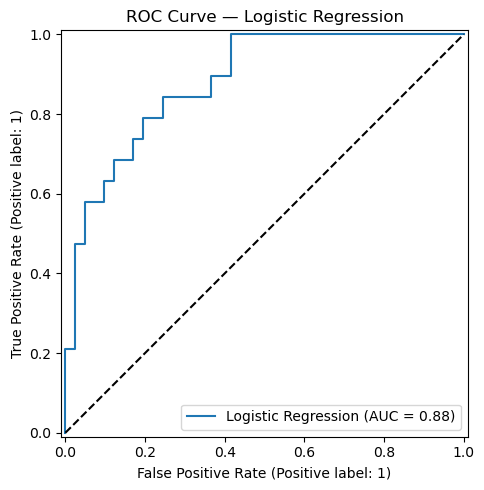

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Train
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predict
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

# ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name="Logistic Regression")
ax.plot([0,1],[0,1], 'k--', label='Random baseline')
ax.set_title('ROC Curve — Logistic Regression')
plt.tight_layout()
plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' automatically corrects for imbalance
lr_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)

y_pred_b = lr_balanced.predict(X_test_scaled)
y_prob_b = lr_balanced.predict_proba(X_test_scaled)[:, 1]

print("Balanced Classification Report:")
print(classification_report(y_test, y_pred_b, target_names=['Survived', 'Died']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_b):.3f}")

Balanced Classification Report:
              precision    recall  f1-score   support

    Survived       0.83      0.85      0.84        41
        Died       0.67      0.63      0.65        19

    accuracy                           0.78        60
   macro avg       0.75      0.74      0.75        60
weighted avg       0.78      0.78      0.78        60

AUC-ROC: 0.872


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Survived', 'Died']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.3f}")

Random Forest Report:
              precision    recall  f1-score   support

    Survived       0.86      0.88      0.87        41
        Died       0.72      0.68      0.70        19

    accuracy                           0.82        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.81      0.82      0.82        60

AUC-ROC: 0.884


In [29]:
!pip install xgboost --quiet

from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, 
                    scale_pos_weight=2,  # handles imbalance (majority/minority ratio)
                    eval_metric='logloss', verbosity=0)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Survived', 'Died']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.3f}")

XGBoost Report:
              precision    recall  f1-score   support

    Survived       0.82      0.88      0.85        41
        Died       0.69      0.58      0.63        19

    accuracy                           0.78        60
   macro avg       0.75      0.73      0.74        60
weighted avg       0.78      0.78      0.78        60

AUC-ROC: 0.843


In [33]:
xgb_tuned = XGBClassifier(n_estimators=50, max_depth=3, 
                           learning_rate=0.1, scale_pos_weight=2,
                           random_state=42, eval_metric='logloss', verbosity=0)
xgb_tuned.fit(X_train_scaled, y_train)

y_pred_xt = xgb_tuned.predict(X_test_scaled)
y_prob_xt = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

print("XGBoost Tuned Report:")
print(classification_report(y_test, y_pred_xt, target_names=['Survived', 'Died']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xt):.3f}")

XGBoost Tuned Report:
              precision    recall  f1-score   support

    Survived       0.86      0.88      0.87        41
        Died       0.72      0.68      0.70        19

    accuracy                           0.82        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.81      0.82      0.82        60

AUC-ROC: 0.834


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.2 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.0 which is incompatible.


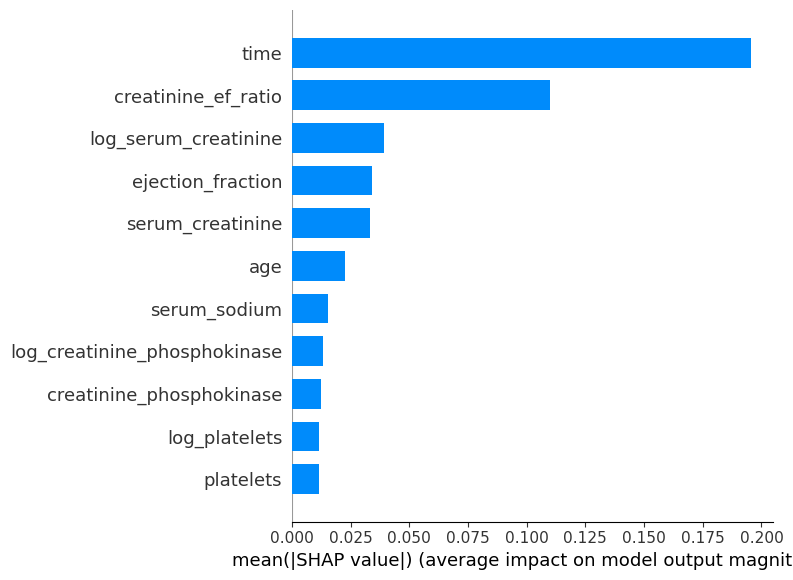

In [35]:
!pip install shap --quiet
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot — feature importance across all predictions
shap.summary_plot(shap_values[:,:,1], X_test_scaled, 
                  feature_names=continuous,
                  plot_type="bar", show=True)

In [37]:
continuous_no_time = [f for f in continuous if f != 'time']

X_train_nt, X_test_nt, y_train_nt, y_test_nt = train_test_split(
    df[continuous_no_time], y, test_size=0.2, random_state=42, stratify=y)

scaler_nt = StandardScaler()
X_train_nt_scaled = scaler_nt.fit_transform(X_train_nt)
X_test_nt_scaled = scaler_nt.transform(X_test_nt)

rf_nt = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_nt.fit(X_train_nt_scaled, y_train_nt)

y_pred_nt = rf_nt.predict(X_test_nt_scaled)
y_prob_nt = rf_nt.predict_proba(X_test_nt_scaled)[:, 1]

print("RF Without Time:")
print(classification_report(y_test_nt, y_pred_nt, target_names=['Survived', 'Died']))
print(f"AUC-ROC: {roc_auc_score(y_test_nt, y_prob_nt):.3f}")

RF Without Time:
              precision    recall  f1-score   support

    Survived       0.76      0.83      0.79        41
        Died       0.53      0.42      0.47        19

    accuracy                           0.70        60
   macro avg       0.64      0.63      0.63        60
weighted avg       0.69      0.70      0.69        60

AUC-ROC: 0.772


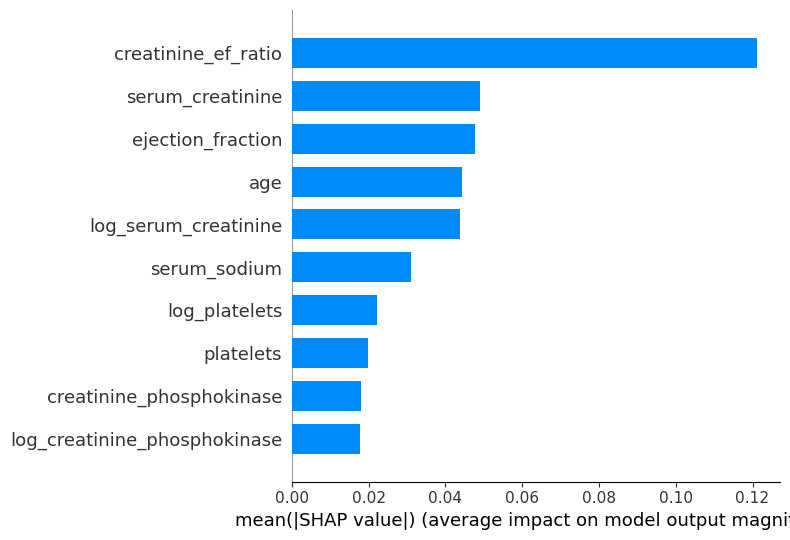

In [39]:
explainer_nt = shap.TreeExplainer(rf_nt)
shap_values_nt = explainer_nt.shap_values(X_test_nt_scaled)

shap.summary_plot(shap_values_nt[:,:,1], X_test_nt_scaled,
                  feature_names=continuous_no_time,
                  plot_type="bar", show=True)

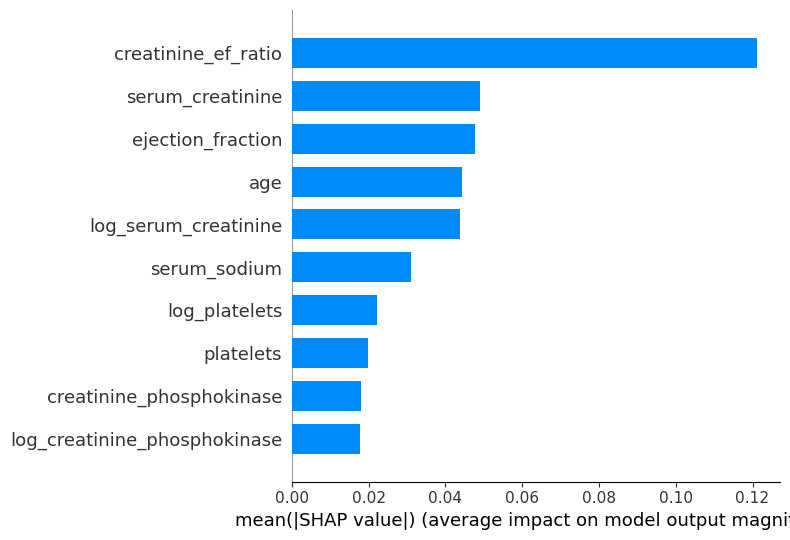

In [41]:
import matplotlib.pyplot as plt

plt.figure()
explainer_nt = shap.TreeExplainer(rf_nt)
shap_values_nt = explainer_nt.shap_values(X_test_nt_scaled)

shap.summary_plot(shap_values_nt[:,:,1], X_test_nt_scaled,
                  feature_names=continuous_no_time,
                  plot_type="bar", show=True)

In [43]:
print(continuous_no_time)

['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'log_serum_creatinine', 'log_creatinine_phosphokinase', 'log_platelets', 'creatinine_ef_ratio']
